<a href="https://colab.research.google.com/github/hazra-kerubo/Logistic-Model/blob/main/Logistic_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question**

Build a logistic regression model to predict the proportion of putts made (success) based
on length (in feet) given the following golf putts table.

In [ ]:
#  Importing Libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [ ]:
#  Input the data
length = np.array([3, 4, 5, 6, 7])
made = np.array([84, 88, 61, 61, 44])
missed = np.array([17, 31, 47, 64, 90])
total = made + missed

#  Prepare the DataFrame
data = pd.DataFrame({
    'Length': length,
    'Made': made,
    'Missed': missed,
    'Total': total
})

In [ ]:
data

,Length,Made,Missed,Total
0,3,84,17,101
1,4,88,31,119
2,5,61,47,108
3,6,61,64,125
4,7,44,90,134


In [ ]:
# Build the logistic regression model
X = sm.add_constant(data['Length'])  # Add intercept
y = data[['Made', 'Missed']]         # Successes and failures
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()

In [ ]:
#  Print model summary
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     ['Made', 'Missed']   No. Observations:                    5
Model:                            GLM   Df Residuals:                        3
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13.088
Date:                Tue, 08 Apr 2025   Deviance:                       1.0692
Time:                        19:09:31   Pearson chi2:                     1.08
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2568      0.369      8.828      0.0

In [ ]:
#  Predict probabilities over a range of putt lengths
length_range = np.linspace(3, 7, 100)
X_pred = sm.add_constant(length_range)
predicted_probs = model.predict(X_pred)

In [ ]:
X_pred

array([[1.        , 3.        ],
       [1.        , 3.04040404],
       [1.        , 3.08080808],
       [1.        , 3.12121212],
       [1.        , 3.16161616],
       [1.        , 3.2020202 ],
       [1.        , 3.24242424],
       [1.        , 3.28282828],
       [1.        , 3.32323232],
       [1.        , 3.36363636],
       [1.        , 3.4040404 ],
       [1.        , 3.44444444],
       [1.        , 3.48484848],
       [1.        , 3.52525253],
       [1.        , 3.56565657],
       [1.        , 3.60606061],
       [1.        , 3.64646465],
       [1.        , 3.68686869],
       [1.        , 3.72727273],
       [1.        , 3.76767677],
       [1.        , 3.80808081],
       [1.        , 3.84848485],
       [1.        , 3.88888889],
       [1.        , 3.92929293],
       [1.        , 3.96969697],
       [1.        , 4.01010101],
       [1.        , 4.05050505],
       [1.        , 4.09090909],
       [1.        , 4.13131313],
       [1.        , 4.17171717],
       [1.

In [ ]:
predicted_probs

array([0.82612556, 0.82281528, 0.81945575, 0.81604677, 0.81258813,
       0.80907969, 0.80552128, 0.80191279, 0.79825411, 0.79454517,
       0.79078591, 0.78697632, 0.78311638, 0.77920612, 0.77524559,
       0.77123488, 0.76717409, 0.76306337, 0.75890287, 0.75469281,
       0.7504334 , 0.74612492, 0.74176765, 0.73736192, 0.73290809,
       0.72840655, 0.72385772, 0.71926208, 0.7146201 , 0.70993233,
       0.70519931, 0.70042166, 0.6956    , 0.690735  , 0.68582737,
       0.68087784, 0.67588718, 0.67085621, 0.66578576, 0.6606767 ,
       0.65552996, 0.65034646, 0.64512719, 0.63987315, 0.63458539,
       0.62926497, 0.62391299, 0.61853059, 0.61311892, 0.60767918,
       0.60221258, 0.59672035, 0.59120377, 0.58566412, 0.58010273,
       0.57452091, 0.56892003, 0.56330147, 0.55766661, 0.55201687,
       0.54635367, 0.54067845, 0.53499265, 0.52929775, 0.52359521,
       0.51788651, 0.51217313, 0.50645658, 0.50073833, 0.4950199 ,
       0.48930276, 0.48358842, 0.47787837, 0.4721741 , 0.46647

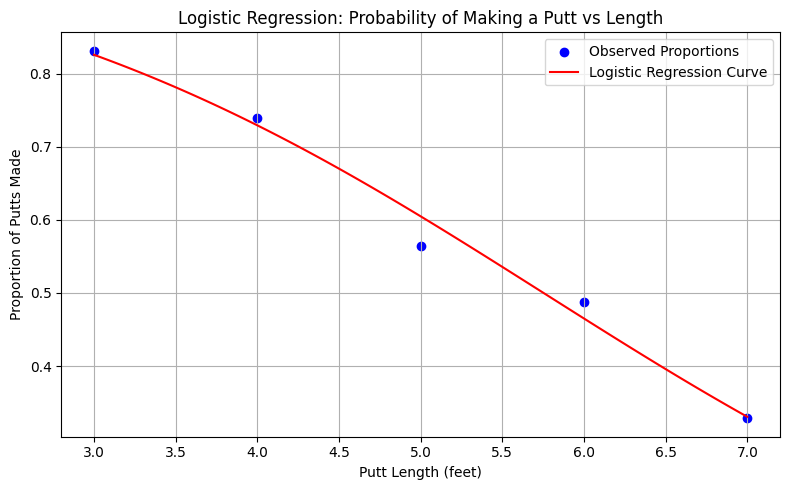

In [ ]:

# SPlot the results
observed_proportions = made / total

plt.figure(figsize=(8, 5))
plt.scatter(length, observed_proportions, color='blue', label='Observed Proportions')
plt.plot(length_range, predicted_probs, color='red', label='Logistic Regression Curve')
plt.xlabel('Putt Length (feet)')
plt.ylabel('Proportion of Putts Made')
plt.title('Logistic Regression: Probability of Making a Putt vs Length')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#  Working prediction function
def predict_putt_probability(length_in_feet):
    # Convert to DataFrame to match model input format
    new_data = pd.DataFrame({'const': [1], 'Length': [length_in_feet]})
    prob = model.predict(new_data)[0]
    print(f"Probability of making a {length_in_feet}-foot putt: {prob:.2%}")
    return prob

In [ ]:
#  Predict for a 5.5-foot putt
predict_putt_probability(5.5)

Probability of making a 5.5-foot putt: 53.57%


np.float64(0.5357039059017848)

In [ ]:
#  Predict for a 10.5-foot putt
predict_putt_probability(10.5)

Probability of making a 10.5-foot putt: 6.37%


np.float64(0.06370608561722825)

In [ ]:
#  Predict for a 2 -foot putt
predict_putt_probability(2)

Probability of making a 2-foot putt: 89.33%


np.float64(0.8932669896431549)

**Conclusion**

* There is a negative relationship between Length and Success
* The coefficient for Length is negative, which means:
   As the distance of the putt increases, the probability of making the putt decreases.
* Longer putts are harder to make.
* Between 3 and 7 feet, there’s a steep decline in the probability of success.
* Probability of making a 5.5-foot putt: 53.57%

**Use cases**

* This model help players understand which putts are most important to practice.

* Players Make decisions on when to play safe vs. aggressive based on
  success probabilities.


